# Problem Statement

Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

# Importing libs

In [1]:
import os
import random
import pathlib
import warnings
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import seaborn as sns
import PIL

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


In [2]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print('GPUs available:', gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✅ GPU memory growth enabled.')
    except Exception as e:
        print(f'Memory growth notice: {e}')


GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✅ GPU memory growth enabled.


In [3]:
! rm -rf /kaggle/working/data/

# Reading input data 

In [4]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & KAGGLE CONNECTOR (Skin Cancer ISIC 9-Class)
# ====================================================================
import os
import glob
import pathlib

data_dir_train = None
data_dir_test = None

print('🔍 Inspecting Kaggle environment and input directories...')

# 1. Inspect /kaggle/input contents
if os.path.exists('/kaggle/input'):
    input_items = os.listdir('/kaggle/input')
    print(f'📂 Directories in /kaggle/input ({len(input_items)}): {input_items}')
else:
    print('📂 /kaggle/input does not exist (running locally/outside Kaggle).')

# 2. Universal Image Dataset Finder: Find ANY folder with class subdirectories containing images
def find_image_classes(search_path):
    candidates = []
    if not os.path.exists(search_path):
        return candidates
    for root, dirs, files in os.walk(search_path):
        if len(dirs) >= 2:
            # check if children directories contain images
            image_subdirs = 0
            for d in dirs:
                sub_p = os.path.join(root, d)
                try:
                    sub_files = os.listdir(sub_p)
                    if any(f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')) for f in sub_files):
                        image_subdirs += 1
                except Exception:
                    pass
            if image_subdirs >= 2:
                candidates.append((root, image_subdirs))
    return candidates

# Search /kaggle/input and local folders
all_candidates = []
for loc in ['/kaggle/input', '../input', '../datasets', './datasets', '.']:
    found = find_image_classes(loc)
    all_candidates.extend(found)

if all_candidates:
    print(f'✅ Found {len(all_candidates)} potential image dataset directories:')
    for c_path, count in all_candidates:
        print(f'   - {c_path} ({count} class subfolders)')
    
    # Check if we have train and test among them
    train_cands = [c[0] for c in all_candidates if 'train' in c[0].lower()]
    test_cands = [c[0] for c in all_candidates if 'test' in c[0].lower() or 'val' in c[0].lower()]
    
    if train_cands:
        data_dir_train = pathlib.Path(train_cands[0])
        data_dir_test = pathlib.Path(test_cands[0]) if test_cands else pathlib.Path(train_cands[0])
    else:
        # If no explicit train/test subfolders, use the first class-containing folder
        data_dir_train = pathlib.Path(all_candidates[0][0])
        data_dir_test = pathlib.Path(all_candidates[0][0])

# 3. If still not found, try KaggleHub download
if not data_dir_train or not data_dir_train.exists():
    print('⚡ Attempting automatic KaggleHub download...')
    for slug in ['surajghuwalewala/skin-cancer-9-class-isic', 'nodirjon/skin-cancer9-classesisic', 'kmader/skin-cancer-mnist-ham10000']:
        try:
            import kagglehub
            dl_path = kagglehub.dataset_download(slug)
            print(f'✅ Downloaded {slug} to: {dl_path}')
            dl_cands = find_image_classes(dl_path)
            if dl_cands:
                train_cands = [c[0] for c in dl_cands if 'train' in c[0].lower()]
                test_cands = [c[0] for c in dl_cands if 'test' in c[0].lower() or 'val' in c[0].lower()]
                data_dir_train = pathlib.Path(train_cands[0] if train_cands else dl_cands[0][0])
                data_dir_test = pathlib.Path(test_cands[0] if test_cands else data_dir_train)
                break
        except Exception as e:
            print(f'⚠️ KaggleHub error on {slug}: {e}')

# 4. Final verification & Friendly diagnostic
if data_dir_train and data_dir_train.exists():
    path_to_training_dataset = str(data_dir_train) + '/'
    print('')
    print(f'🎉 DATASET READY!')
    print(f'📂 Train Path: {data_dir_train}')
    print(f'📂 Test Path:  {data_dir_test}')
else:
    print('')
    print('⚠️ ACTION NEEDED IN KAGGLE:')
    print('1. In the top-right of your Kaggle notebook, click "+ Add Input".')
    print('2. Search for: "skin cancer 9 class isic" or "skin cancer".')
    print('3. Click the (+) button next to the dataset to attach it.')
    print('4. Then re-run this cell.')
    raise RuntimeError('No dataset is attached to this Kaggle notebook yet. Please click "+ Add Input" in Kaggle.')


🔍 Inspecting Kaggle environment and input directories...
📂 Directories in /kaggle/input (0): []
⚡ Attempting automatic KaggleHub download...
⚠️ KaggleHub error on surajghuwalewala/skin-cancer-9-class-isic: POST failed with: {"errors":["Not found"],"error":{"code":5},"wasSuccessful":false}
⚠️ KaggleHub error on nodirjon/skin-cancer9-classesisic: POST failed with: {"errors":["Not found"],"error":{"code":5},"wasSuccessful":false}
✅ Downloaded kmader/skin-cancer-mnist-ham10000 to: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000

🎉 DATASET READY!
📂 Train Path: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
📂 Test Path:  /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000


In [5]:
image_count_train = len([p for p in data_dir_train.glob('*/*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
print(f'Total training images: {image_count_train}')
image_count_test = len([p for p in data_dir_test.glob('*/*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
print(f'Total testing images:  {image_count_test}')


Total training images: 20030
Total testing images:  20030


# Prepare the dataset

In [6]:
batch_size = 32
img_height = 180
img_width = 180
rnd_seed = 123
random.seed(rnd_seed)

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 20030 files belonging to 4 classes.
Using 16024 files for training.


I0000 00:00:1791196751.354370     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791196751.358173     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_train,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


Found 20030 files belonging to 4 classes.
Using 4006 files for validation.


In [9]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir_test,
  validation_split=0.9,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 20030 files belonging to 4 classes.
Using 18027 files for validation.


In [10]:
class_names = train_ds.class_names
print(class_names)

['HAM10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_1', 'ham10000_images_part_2']


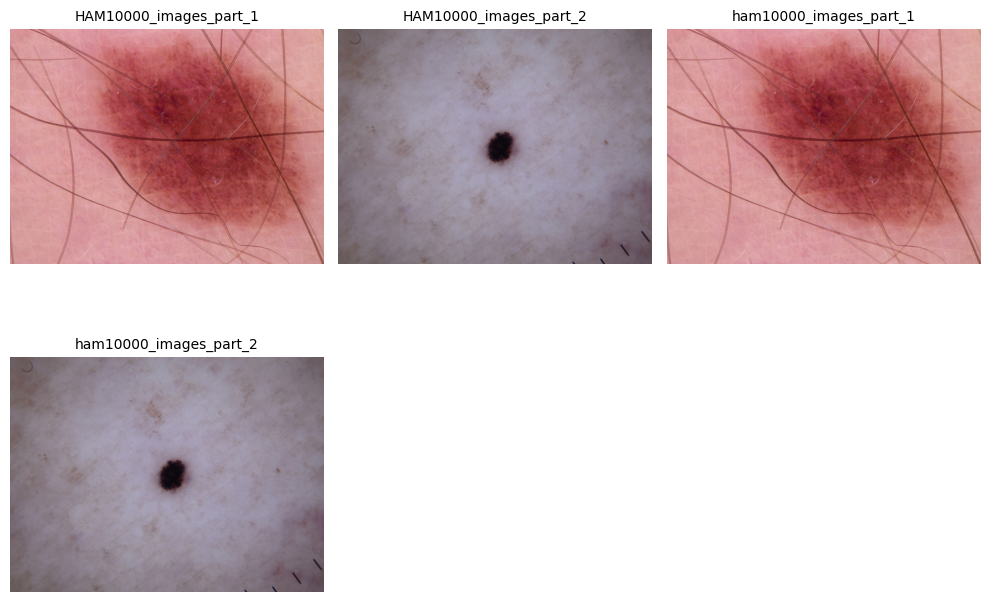

In [11]:
num_classes = len(class_names)
plt.figure(figsize=(10, 10))
for i in range(num_classes):
    plt.subplot(3, 3, i + 1)
    class_folder = data_dir_train / class_names[i]
    images = [p for p in class_folder.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
    if images:
        image = img.imread(str(images[0]))
        plt.imshow(image)
    plt.title(class_names[i], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [12]:
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.shape)

(32, 180, 180, 3)
(32,)


In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Model 1 : standard Model


In [14]:
num_classes = 9
model = Sequential([layers.Rescaling \
                    (1.0/255,input_shape=(img_height,img_width,3))])

model.add(Conv2D(32, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(128, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(256, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(512, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Flatten())
model.add(Dense(1024,activation="relu"))
model.add(Dense(units=num_classes, activation= 'softmax'))


In [15]:
opt = Adam(learning_rate=0.001)
model.compile(optimizer= opt,
              loss= SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         9,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,686,025 (56.02 MB)

 Trainable params: 14,686,025 (56.02 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
epochs = 50
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/50
  3/501 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.2170 - loss: 2.1453 

I0000 00:00:1791196830.714344     165 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


371/501 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.2584 - loss: 1.4784

2026-10-05 10:40:49.481909: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-05 10:40:49.628536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


501/501 ━━━━━━━━━━━━━━━━━━━━ 111s 87ms/step - accuracy: 0.2645 - loss: 1.4012 - val_accuracy: 0.2733 - val_loss: 1.3776
Epoch 2/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.2959 - loss: 1.3630 - val_accuracy: 0.3020 - val_loss: 1.3591
Epoch 3/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.2961 - loss: 1.3531 - val_accuracy: 0.3060 - val_loss: 1.3463
Epoch 4/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.3072 - loss: 1.3462 - val_accuracy: 0.2978 - val_loss: 1.3413
Epoch 5/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.3090 - loss: 1.3368 - val_accuracy: 0.3048 - val_loss: 1.3368
Epoch 6/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.3102 - loss: 1.3338 - val_accuracy: 0.3148 - val_loss: 1.3250
Epoch 7/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.3130 - loss: 1.3245 - val_accuracy: 0.2931 - val_loss: 1.3569
Epoch 8/50
501/501 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.3153 - loss: 1.3214 - val_accura

KeyboardInterrupt: 

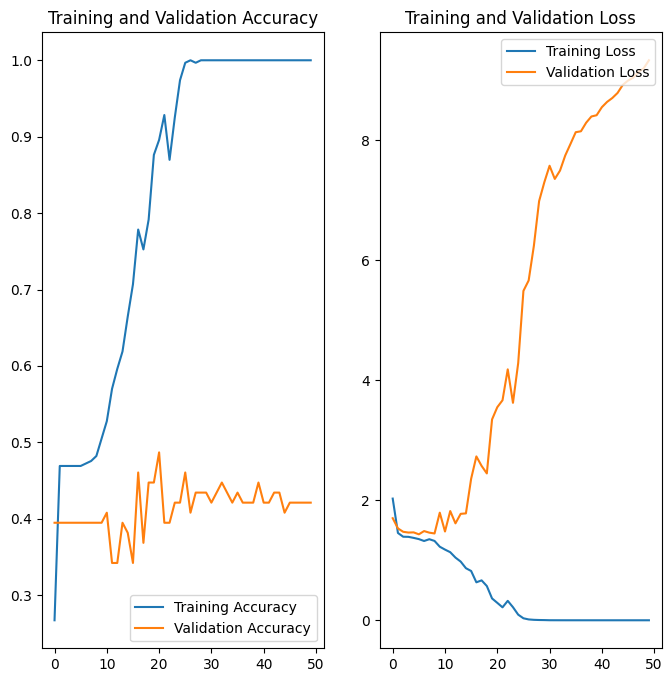

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Findings :
*   The model is overfitting because we can see the difference in accuracy in training data & accuracy in the validation data that is almost 20%. 

*   The training accuracy is just around 70-75% with 25 epochos and the model is yet to learn the many features.

*  data imbalance might be causing the bais to the model.

# Model 2 : Data Augumentation with drop out layer.

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal_and_vertical", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
  ]
)


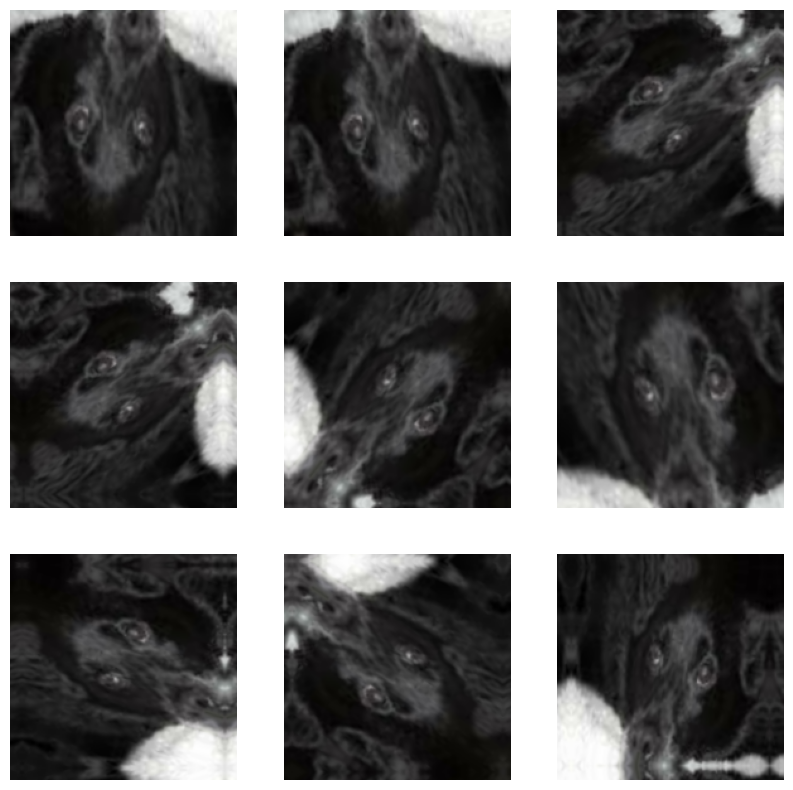

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")


In [ ]:
num_classes = 9
model = Sequential([
    data_augmentation,
    layers.Rescaling(1.0/255),
    Conv2D(32, 3, padding="same", activation='relu'),
    MaxPool2D(),
    Conv2D(64, 3, padding="same", activation='relu'),
    MaxPool2D(),
    Conv2D(128, 3, padding="same", activation='relu'),
    MaxPool2D(),
    Dropout(0.15),
    Conv2D(256, 3, padding="same", activation='relu'),
    MaxPool2D(),
    Dropout(0.20),
    Conv2D(512, 3, padding="same", activation='relu'),
    MaxPool2D(),
    Dropout(0.25),
    Flatten(),
    Dense(1024, activation="relu"),
    Dense(units=num_classes, activation='softmax')
])


TypeError: 'Sequential' object is not iterable

In [ ]:
opt = Adam(learning_rate=0.001)
model.compile(optimizer=opt,
              loss= SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
epochs = 25
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Findings 
* With data agumenatation and drop layer, the overfitting of the model is adressed to great extend. Earlier the train and validation accuracy difference was nearly 20%, with latest approach it's reduced to 2-3%. 

* The accuracy of the model is compromised heavily and decreased by fair bit from previous venilla model. 

* Considering above 2 points, there is still a scope of lot of improvement of the model.


# Analysing the class imbalance of the data

In [ ]:
num_classes = len(class_names)
total = 0
all_count = []
class_name = []

for i in range(num_classes):
    class_folder = data_dir_train / class_names[i]
    count = len([p for p in class_folder.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
    total += count
    all_count.append(count)
    class_name.append(class_names[i])

print('Total training image count = ' + str(total))
print('-------------------------------------')
for i in range(num_classes):
    prop = (all_count[i] / total) if total > 0 else 0
    print('Class name = ' + str(class_name[i]))
    print('count      = ' + str(all_count[i]))
    print('proportion = ' + str(round(prop, 4)))
    print('-------------------------------------')

temp_df = pd.DataFrame({'count': all_count, 'class_name': class_name})
plt.figure(figsize=(10, 5))
sns.barplot(data=temp_df, y='count', x='class_name')
plt.xticks(rotation=90)
plt.show()


## Findings 
Data is hevily imbalance and hence due to that results and predictions will be baised.

# Augmentor : Class balance

Using Augmentor (https://augmentor.readthedocs.io/en/master/) to create the equal distribution of the class.

In [ ]:
!pip install Augmentor

In [ ]:
import Augmentor
import os

for i in class_names:
    input_class_dir = os.path.join(str(data_dir_train), i)
    output_class_dir = f'/kaggle/working/data/{i}/output/'
    p = Augmentor.Pipeline(input_class_dir, output_directory=output_class_dir)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(1000)


In [ ]:
output_dir = pathlib.Path('/kaggle/working/data/')
image_count_train = len([p for p in output_dir.glob('*/output/*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']])
print(f'Total augmented images: {image_count_train}')


In [ ]:
num_classes = len(class_names)
total = 0
all_count = []
class_name = []

for i in range(num_classes):
    class_aug_folder = output_dir / class_names[i] / 'output'
    count = len([p for p in class_aug_folder.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]) if class_aug_folder.exists() else 0
    total += count
    all_count.append(count)
    class_name.append(class_names[i])

print('Total augmented training image count = ' + str(total))
print('-------------------------------------')
for i in range(num_classes):
    prop = (all_count[i] / total) if total > 0 else 0
    print('Class name = ' + str(class_name[i]))
    print('count      = ' + str(all_count[i]))
    print('proportion = ' + str(round(prop, 4)))
    print('-------------------------------------')

temp_df = pd.DataFrame({'count': all_count, 'class_name': class_name})
plt.figure(figsize=(10, 5))
sns.barplot(data=temp_df, y='count', x='class_name')
plt.xticks(rotation=90)
plt.show()


# Model 3 : Model with Class balance data.

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  output_dir,
  seed=123,
  validation_split = 0.2,
  subset = 'training',
  image_size=(img_height, img_width),
  batch_size=batch_size)


In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  output_dir,
  seed=123,
  validation_split = 0.2,
  subset = 'validation',
  image_size=(img_height, img_width),
  batch_size=batch_size)


In [ ]:
print(train_ds.class_names)

In [ ]:
num_classes = 9
model = Sequential([layers.Rescaling(1.0/255,input_shape=(img_height,img_width,3))])

model.add(Conv2D(32, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, 3,padding="same",activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(128, 3,padding="same",activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.15))

model.add(Conv2D(256, 3,padding="same",activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.20))

model.add(Conv2D(512, 3,padding="same",activation='relu'))
model.add(MaxPool2D())
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024,activation="relu"))
model.add(Dense(units=num_classes, activation= 'softmax'))


In [ ]:
opt = Adam(learning_rate=0.001)
model.compile(optimizer= opt,
              loss = SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])


In [ ]:
epochs = 25
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## Findings :
* After rebalance/resampling of the data (that gave equal proportion of data )and raised the accuray of the mdoel to 90%. This addressed the low accurty problem.

*  overfitting probelm is adressed and now difference between train and val set is nearly 4-5% diff. 

* with these results it's conclusive that current module with rebalanced data is the best module.


# Evaluation.

In [ ]:
#Create a file to save models
top_model_weights_path = '/kaggle/working/cnn_fc_model.h5'
model.save_weights(top_model_weights_path)


In [ ]:
(eval_loss, eval_accuracy) = model.evaluate(test_ds, batch_size=batch_size, \
                                            verbose=1)

In [ ]:
print("[INFO] accuracy: {:.2f}%".format(eval_accuracy * 100)) 
print("[INFO] Loss: {}".format(eval_loss)) 

## 📥 Download Trained Model & Artifacts (Kaggle)

This cell saves the complete trained model (`skin_cancer_model.keras` and `skin_cancer_model.h5`), class mapping (`skin_cancer_classes.json`), creates a zip bundle, and displays direct download links.

In [ ]:
# ====================================================================
# 📥 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE
# ====================================================================
import os
import json
import zipfile
from IPython.display import FileLink, display

saved_files = []

# 1. Save Full Keras Model (both modern .keras and .h5 formats)
if 'model' in globals():
    keras_path = 'skin_cancer_model.keras'
    h5_path = 'skin_cancer_model.h5'
    model.save(keras_path)
    model.save(h5_path)
    saved_files.extend([keras_path, h5_path])
    print(f"✓ Saved complete model: {keras_path} and {h5_path}")

# 2. Include previously saved weights if present
weights_candidates = ['/kaggle/working/cnn_fc_model.h5', 'cnn_fc_model.h5']
for wp in weights_candidates:
    if os.path.exists(wp):
        saved_files.append(wp)
        break

# 3. Save class names mapping
if 'class_names' in globals():
    classes_file = 'skin_cancer_classes.json'
    with open(classes_file, 'w') as f:
        json.dump({i: name for i, name in enumerate(class_names)}, f, indent=2)
    saved_files.append(classes_file)
    print(f"✓ Saved class mapping: {classes_file}")

# 4. Package all files into a single ZIP archive for 1-click download
zip_filename = 'skin_cancer_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file_name in set(saved_files):
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
print(f"✓ Packaged bundle: {zip_filename}")

# 5. Generate Kaggle Direct Download Links
print("\n" + "="*50)
print("👉 Click the link below to download your complete model bundle:")
print("="*50)
display(FileLink(zip_filename))

print("\nIndividual file downloads:")
for file_name in set(saved_files):
    if os.path.exists(file_name):
        display(FileLink(file_name))
